# Midterm Project 3 (100 points total)

## In this project, you need to use neural networks: Build a Feed-forward Neural Network and a Convolutional Neural Network using Keras library to classify patients with heart conditions.

### Import the necessary libraries. (5 points)

In [1]:
#Import the necessary libraries.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import seaborn as sns
from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix

from keras.models import Sequential
from keras.layers import Dense, Conv1D, MaxPooling1D, Flatten
from keras.callbacks import EarlyStopping
# from keras.utils import to_categorical
from tensorflow.keras.utils import to_categorical


### After that, upload the data and preprocess it. (20 points)

In [2]:
#Upload the data and save it to a Dataframe.
data = pd.read_csv('Heartbeat_dataset.csv', header=None)
data=pd.DataFrame(data)

0.0    72471
4.0     6431
2.0     5788
1.0     2223
3.0      641
Name: 187, dtype: int64
0.0    8000
4.0    6431
2.0    5788
1.0    2223
3.0     641
Name: 187, dtype: int64


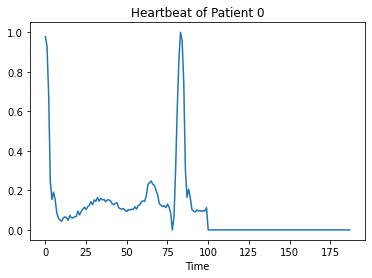

In [3]:
#Plot the heartbeat of one patient.
plt.plot(data.loc[0,:])
plt.xlabel('Time')
plt.title('Heartbeat of Patient 0')

# Check the class distribution. (Hint: Use .value_counts attribute and 
# remember that the labels are at the last column of the dataframe)
print(data.loc[:,187].value_counts())

# You should see that class 0 has more than 5 times as many instances as all other classes combined.
# Make the dataset more balanced by sampling the instances with class 0.
# Filter all the data that don't have class 0 to a new dataframe.
data0 = data.loc[:72470,:]
data_not0 = data.loc[72471:,:]

# From all the data that has class 0 (again use filtering), sample 8000 instances and save it to a new dataframe. 
#(Hint: Use .sample attribute)
data0 = data0.sample(n = 8000, random_state=12)

# Concatenate the two new dataframes.
frames = [data0, data_not0]
samp_data = pd.concat(frames)

# Check the new class distribution.
print(samp_data.loc[:,187].value_counts())
# Finally, separate the features and the labels into X and y variables.
y = data.loc[:,187]
X = data.loc[:,:186]

### Split the data into training and test sets. Use a 90-10 split ratio.

In [4]:
#Create the training and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.1)

#Convert the sets into NumPy arrays (Necessary for Keras models)
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)


### Create a feed-forward neural network with 5 layers. (One input, three hidden, one output) (20 points)

In [5]:
# Create the network using the Keras layers. (Use 512, 100 and 20 nodes for the hidden layers.)

y_train_target = to_categorical(y_train)
y_test_target = to_categorical(y_test)

model = Sequential()

#first hidden layer
model.add(Dense(512, activation='relu', kernel_initializer='glorot_uniform'))


#second hidden layer
model.add(Dense(100, activation='relu', kernel_initializer='glorot_uniform'))


#Third hidden layer
model.add(Dense(20, activation='relu', kernel_initializer='glorot_uniform'))


#Output layer (Binary classification)
model.add(Dense(5, activation='softmax', kernel_initializer='glorot_uniform'))

# Compile and train the network. (Do not forget to expand the training labels into multiple columns.)
#Use val data to early stop
# early_stop = EarlyStopping(monitor='val_loss', patience=5)

#Compile the network
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


### Evaluate your neural network with the test data. You need to achieve 90+% test accuracy for full credit. (5 points)

Epoch 1/10
2217/2217 [==============================] - 29s 3ms/step - loss: 0.3260 - accuracy: 0.9095 - val_loss: 0.1412 - val_accuracy: 0.9595
Epoch 2/10
2217/2217 [==============================] - 5s 2ms/step - loss: 0.1407 - accuracy: 0.9591 - val_loss: 0.1206 - val_accuracy: 0.9638
Epoch 3/10
2217/2217 [==============================] - 5s 2ms/step - loss: 0.1166 - accuracy: 0.9665 - val_loss: 0.0970 - val_accuracy: 0.9726
Epoch 4/10
2217/2217 [==============================] - 5s 2ms/step - loss: 0.1008 - accuracy: 0.9703 - val_loss: 0.1003 - val_accuracy: 0.9717
Epoch 5/10
2217/2217 [==============================] - 5s 2ms/step - loss: 0.0893 - accuracy: 0.9739 - val_loss: 0.0893 - val_accuracy: 0.9761
Epoch 6/10
2217/2217 [==============================] - 5s 2ms/step - loss: 0.0830 - accuracy: 0.9750 - val_loss: 0.0776 - val_accuracy: 0.9779
Epoch 7/10
2217/2217 [==============================] - 5s 2ms/step - loss: 0.0750 - accuracy: 0.9773 - val_loss: 0.0899 - val_accuracy

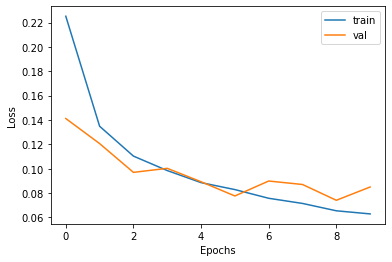

In [6]:
# Get the predictions and convert the multicolumn array into class predictions.
history = model.fit(X_train, y_train_target, validation_split=0.1, epochs=10)
#Evaluate the network
print(model.evaluate(X_test, y_test_target))
y_pred = np.argmax(model.predict(X_test), axis=1)

print(accuracy_score(y_pred, y_test))
print(confusion_matrix(y_pred, y_test))

# Plot the confusion matrix and print the final accuracy.
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['train', 'val'])
plt.show()


### After the feed-forward neural network, train a convolutional neural network (CNN) on the same data. (20 points)

In [7]:
#Add a dimension to each sequence
X_train = np.array(X_train).reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = np.array(X_test).reshape(X_test.shape[0], X_test.shape[1], 1)

# Create the CNN using the Keras layers. (Hint: You can keep the fully-connected part the same as the previous network.)
cnn = Sequential()


cnn.add(Conv1D(32, 3, activation='relu'))
cnn.add(MaxPooling1D(pool_size=5))
cnn.add(Conv1D(32, 3, activation='relu'))
cnn.add(MaxPooling1D(pool_size=5))
cnn.add(Conv1D(64, 3, activation='relu'))
cnn.add(MaxPooling1D(pool_size=5))
cnn.add(Flatten())

cnn.add(Dense(512, activation='relu',  kernel_initializer='glorot_uniform'))
cnn.add(Dense(100, activation='relu',  kernel_initializer='glorot_uniform'))
cnn.add(Dense(20, activation='sigmoid',  kernel_initializer='glorot_uniform'))
cnn.add(Dense(5, activation='softmax', kernel_initializer='glorot_uniform'))

# Compile and train the network.

cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics = ['accuracy'])

# early = EarlyStopping(monitor='val_loss', patience=5)
history1 = cnn.fit(X_train, y_train_target, epochs=10, validation_split=0.1)
cnn.summary()

Epoch 1/10
2217/2217 [==============================] - 20s 7ms/step - loss: 0.2684 - accuracy: 0.7988 - val_loss: 0.2225 - val_accuracy: 0.8305
Epoch 2/10
2217/2217 [==============================] - 15s 7ms/step - loss: 0.1987 - accuracy: 0.8469 - val_loss: 0.0950 - val_accuracy: 0.9214
Epoch 3/10
2217/2217 [==============================] - 15s 7ms/step - loss: 0.0847 - accuracy: 0.9375 - val_loss: 0.0656 - val_accuracy: 0.9534
Epoch 4/10
2217/2217 [==============================] - 15s 7ms/step - loss: 0.0655 - accuracy: 0.9523 - val_loss: 0.0514 - val_accuracy: 0.9645
Epoch 5/10
2217/2217 [==============================] - 14s 6ms/step - loss: 0.0554 - accuracy: 0.9614 - val_loss: 0.0460 - val_accuracy: 0.9657
Epoch 6/10
2217/2217 [==============================] - 13s 6ms/step - loss: 0.0449 - accuracy: 0.9685 - val_loss: 0.0405 - val_accuracy: 0.9720
Epoch 7/10
2217/2217 [==============================] - 13s 6ms/step - loss: 0.0404 - accuracy: 0.9727 - val_loss: 0.0374 - val_ac

### Evaluate your CNN with the test data. You need to beat the feed-forward network accuracy for full credit. (5 points)

274/274 [==============================] - 1s 2ms/step - loss: 0.0337 - accuracy: 0.9758
[0.03368644416332245, 0.9757880568504333]
0.9757880310644129
[[7271   76   61   14    9]
 [  10  135   10    0    0]
 [   8    3  487    4    2]
 [   5    0    5   57    0]
 [   4    0    1    0  594]]


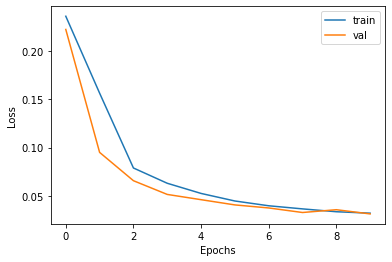

In [8]:
#Evaluate the network
print(cnn.evaluate(X_test, y_test_target))
y_pred = np.argmax(cnn.predict(X_test), axis=1)

print(accuracy_score(y_pred, y_test))
print(confusion_matrix(y_pred, y_test))

# Plot the confusion matrix and print the final accuracy.
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['train', 'val'])
plt.show()

### Answer the following questions: (20 points, 5 each)

### 1) If we haven't undersampled class 0, we would get a even higher accuracy. (You can check yourself.) Why would this be misleading?

#### If we don't, the data would be severely unbalanced. If we trained without undersampling class zero and said all the classes were zero, we still get a high accuracy because the class zero occurs more than 5 times the rest of the other

### 2) In the previous projects, you used 70-30 and 80-20 train-test splits. Why is a 90-10 split enough for this project?

#### With this project, we have a significantly larger data set than other projects so a 90-10 split still offers a large amount of data to test the model 

### 3) Why did we need to add a dimension to the dataset before we fed it into a CNN?

#### Keras requires a 3D tensor input for Conv1D so we have to provide it a 3D tensor input 

### 4) Why does a CNN perform better than a feed-forward neural network for the data in this project?

#### CNNs are better than feed-forward network because they are able to share parameters which allows you to reduce computations. Less parameters  and pooling also reduce the probability of overfitting. They also reduce dimensionality 